# San Mateo County Analysis

In [ ]:
# Import statements
import pandas as pd

from utils import (
    load_ripa_policing_data,
    load_census,
    condense_ripa_races,
    add_search_and_hit_indicators,
    policing_tables_by_year, 
    census_rollup, 
    add_per_capita_rates_by_year, 
    concat_policing_tables,
    compute_prosecution_rates,
    merge_policing_with_prosecution,
    add_disparity_metrics,
    visualization_setup,
    visualize_all_disparity_figures
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [2]:
# Load in policing data
policing = load_ripa_policing_data("san_mateo", years=(2021, 2022)) # Prosecution data only available through 2022

In [3]:
# Load in prosecution data
prosecution = pd.read_excel("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/raw/2014-2022_san-mateo-county_charge-data_redacted-xlsx.xlsx")
prosecution['Year'] = prosecution['OffenseDate'].dt.year

# Select only cases from 2021-2023
prosecution = prosecution[prosecution["Year"].between(2021, 2023)].copy()

In [4]:
# Load in census data
census = load_census("06081")

# Policing Analysis

In [5]:
# Collapse all of the non-relevant racial categories in RIPA data to "Other"
policing = condense_ripa_races(policing)

In [6]:
# Create search and hit columns
policing = add_search_and_hit_indicators(policing)

In [7]:
# Create one policing table per year
tables = policing_tables_by_year(policing, [2021, 2022])

# Roll-up the census data to be more coarse to match policing data hierarchy
census_coarse = census_rollup(census)

# Adds per-capita rates to each table
tables = add_per_capita_rates_by_year(tables, census_coarse)

# Create one big master table with all years and rates
policing_all = concat_policing_tables(tables)
policing_all

,Perceived Race,Search Rate,Hit Rate,Search Count,Hit Count,Stop Count,"Searches per 1,000","Hits per 1,000","Stops per 1,000",Year
0,Asian,0.047809,0.003984,12,1,251,0.052682,0.004390,1.101926,2021
1,Black/African American,0.228188,0.093960,34,14,149,2.312768,0.952316,10.135365,2021
2,Hispanic/Latino,0.109034,0.026480,70,17,642,0.365753,0.088826,3.354477,2021
3,Other,0.061475,0.024590,15,6,244,0.274374,0.109749,4.463142,2021
4,White,0.125142,0.045506,110,40,879,0.398692,0.144979,3.185914,2021
5,Asian,0.042205,0.015207,519,187,12297,2.278484,0.820957,53.985592,2022
6,Black/African American,0.209918,0.097084,1706,789,8127,116.046527,53.669818,552.819536,2022
7,Hispanic/Latino,0.134877,0.050036,4445,1649,32956,23.225314,8.616095,172.196503,2022
8,Other,0.075258,0.026664,779,276,10351,14.249131,5.048473,189.336016,2022
9,White,0.110018,0.047890,3400,1480,30904,12.323216,5.364224,112.010786,2022


# Prosecution Analysis

In [8]:
# Delete rows with invalid race values
# If look at data, can see that there are some incorrect data entry in the columns

valid_races = (
    "Hispanic",
    "White",
    "Black",
    "All Other",
    "Filipino",
    "Other Asian",
    "Pacific Islander",
    "Chinese",
    "Asian Indian",
    "Vietnamese",
    "Samoan",
    "Hawaiian",
    "Unknown",
    "Korean",
    "American Indian",
    "Japanese",
    "Guamanian",
    "Laotian",
    "Cambodian"
)

prosecution = prosecution[prosecution["Race"].isin(valid_races)].copy()

In [9]:
# Relabel races to fit into categories: White, Hispanic/Latino, Black/African American, Asian, Other

RACE_TO_CENSUS = {
    # Direct mappings
    "White": "White",
    "Hispanic": "Hispanic/Latino",
    "Black": "Black/African American",

    # Asian subgroups → Asian
    "Filipino": "Asian",
    "Other Asian": "Asian",
    "Chinese": "Asian",
    "Asian Indian": "Asian",
    "Vietnamese": "Asian",
    "Korean": "Asian",
    "Japanese": "Asian",
    "Cambodian": "Asian",
    "Laotian": "Asian",

    # Pacific Islander & Native → Other
    "Pacific Islander": "Other",
    "Samoan": "Other",
    "Hawaiian": "Other",
    "Guamanian": "Other",
    "American Indian": "Other",

    # Catch-alls
    "All Other": "Other",
    "Unknown": "Other",
}

prosecution["Census Race"] = prosecution["Race"].map(RACE_TO_CENSUS)

In [10]:
# Create column to indicate if convicted or not
CONVICTED_DISPOSITIONS = {
    "Guilty By Jury",
    "Guilty By Court Trial",
    "Guilty Plea",
    "Guilty Plea Agreement",
    "Plead Guilty Plea Agreement",
    "Plead Guilty Nolo Contendere",
    "Pled No Contest",
    "Nolo",
    "Found Guilty Lesser Included Offense Jury",
    "Found Guilty Lesser Included Offense Court",
    "DEJ Unsuccessful / No Contest Plea",
}

case_convicted = (
    prosecution
    .groupby("FileNumber")["ChargeDisposition"]
    .apply(lambda x: x.isin(CONVICTED_DISPOSITIONS).any())
    .astype(int)
)

prosecution = prosecution.merge(
    case_convicted.rename("was_convicted"),
    on="FileNumber",
    how="left",
)

In [11]:
# Create column to indicate if enhancement or not

ENH_TRUE_DISPOSITIONS = {
    "Enhancement Found True Jury",
    "Enhancement Found True Court",
    "Admit Enhancement",
    "Strike enhancement",
}

case_enhanced = (
    prosecution
    .groupby("FileNumber")["EnhDisposition"]
    .apply(lambda x: x.isin(ENH_TRUE_DISPOSITIONS).any())
    .astype(int)
)

prosecution = prosecution.merge(
    case_enhanced.rename("is_enhancement_charge"),
    on="FileNumber",
    how="left"
)

In [12]:
# Create big table of conviction and enhancement rates
prosecution_rates = compute_prosecution_rates(
    prosecution,
    race_col="Census Race",
    year_col="Year",
    convicted_col="was_convicted",
    enhancement_col="is_enhancement_charge"
)

prosecution_rates['Year'] = prosecution_rates['Year'].astype(int)
prosecution_rates

,Census Race,Year,total_cases,conviction_rate,enhancement_rate
0,Asian,2021,2061,0.261038,0.041727
1,Asian,2022,290,0.027586,0.000000
2,Black/African American,2021,4923,0.226691,0.067032
3,Black/African American,2022,720,0.076389,0.005556
4,Hispanic/Latino,2021,13909,0.284204,0.068876
5,Hispanic/Latino,2022,1917,0.086594,0.003652
6,Other,2021,2438,0.242412,0.044299
7,Other,2022,303,0.052805,0.016502
8,White,2021,8384,0.256679,0.062977
9,White,2022,1106,0.084991,0.000904


# Disparity Ratios

In [13]:
# Merge policing and prosecution data into one table based on common policing race label
analysis = merge_policing_with_prosecution(
    policing_all,
    prosecution_rates,
    pros_race_col="Census Race",
    pros_year_col="Year"
)

In [14]:
# Add White-normalized ratios and a search-hit gap
analysis = add_disparity_metrics(analysis)

# Keep plots consistent across runs
analysis = visualization_setup(analysis)

# Visualizations

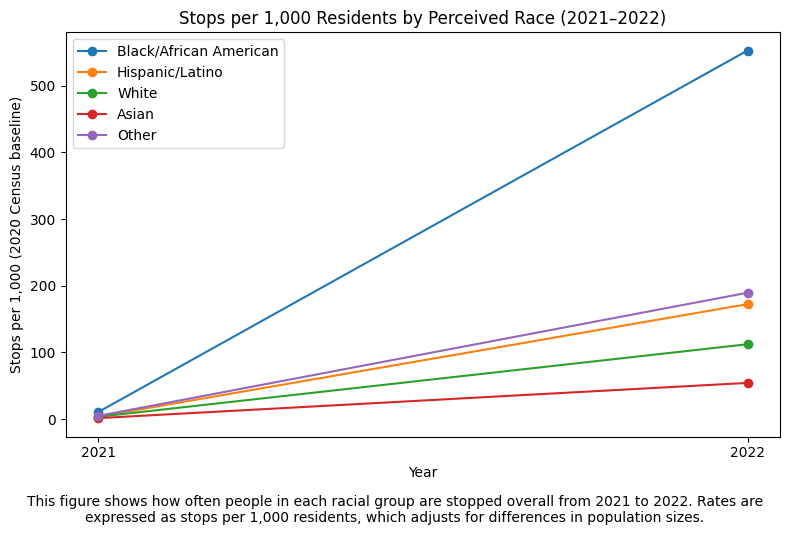

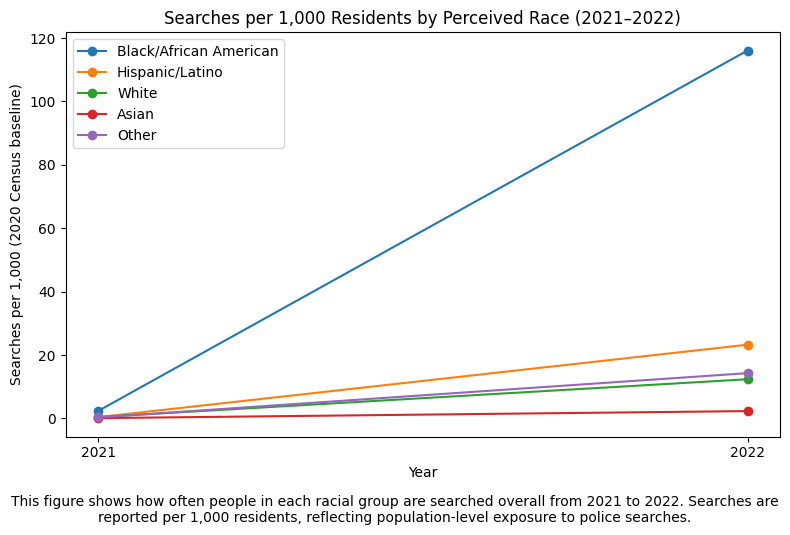

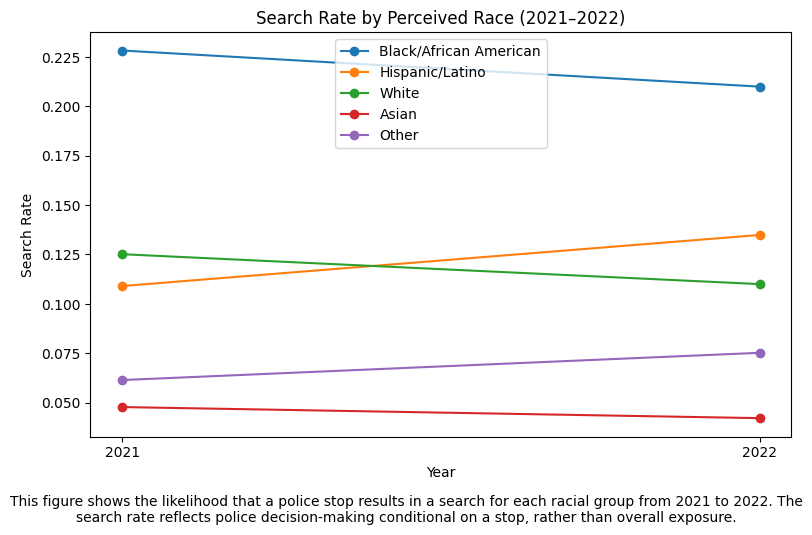

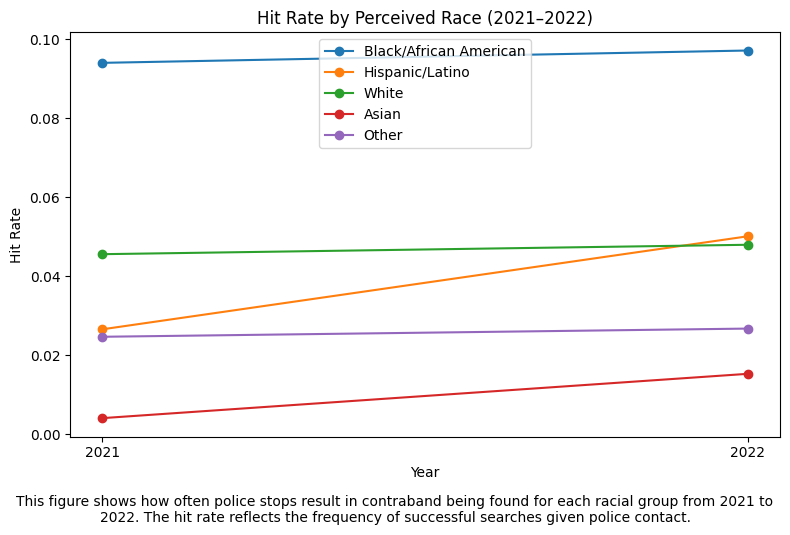

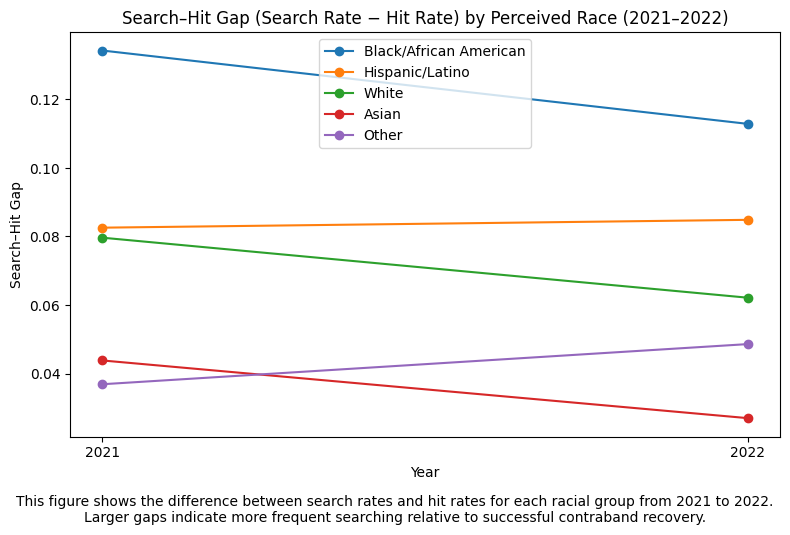

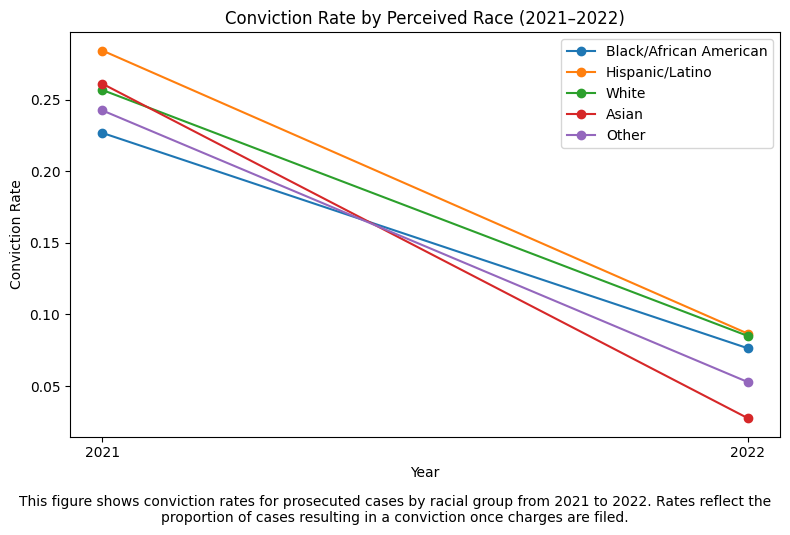

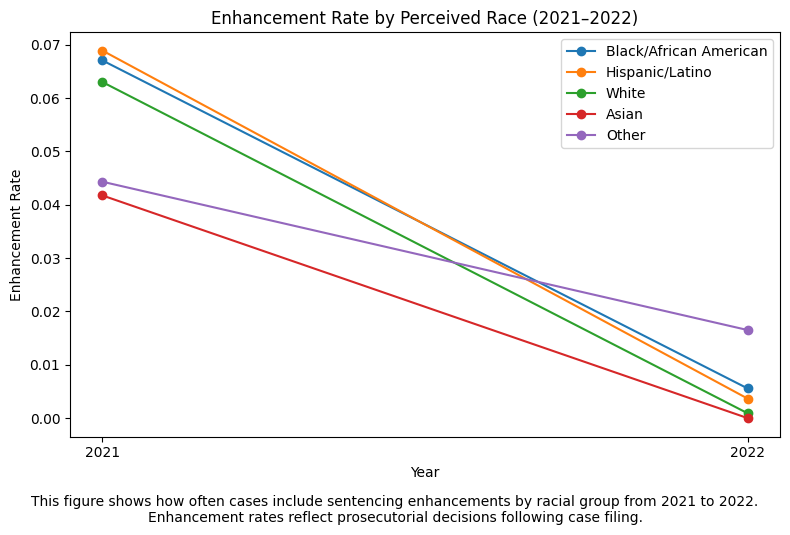

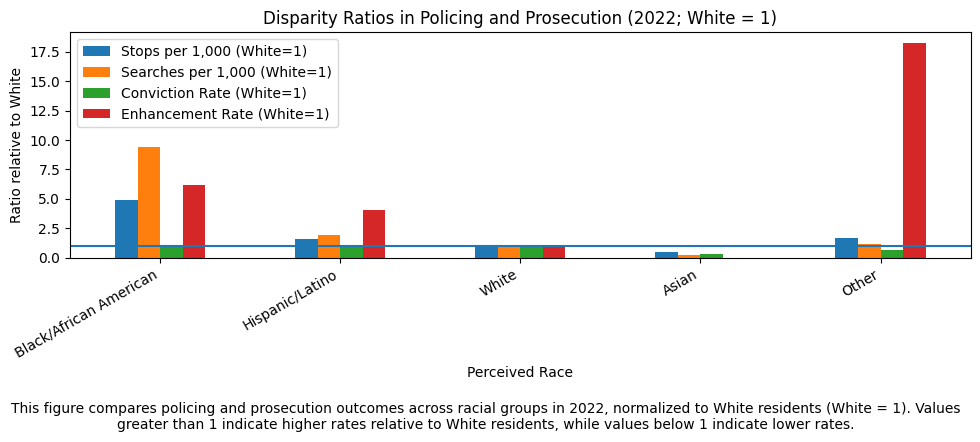

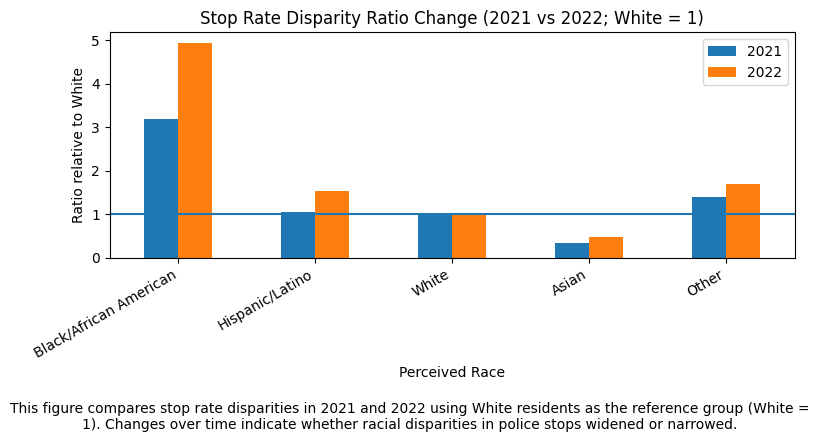

In [15]:
visualize_all_disparity_figures(analysis)